# Лабораторная 7

## 1. Построение описательный статистик двух финансовых активов

### Импорт библиотек:

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, coint
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model

### Загрузка исторических цен (закрытия на конец дня) и расчёт ежедневных доходностей

In [3]:
tickers = ['MSFT', 'AAPL']
start_date = '2020-01-01'
end_date = '2024-12-31'

data = yf.download(tickers, start=start_date, end=end_date)['Close']  # type: ignore
data.dropna(inplace=True)
returns = data.pct_change().dropna()

[*********************100%***********************]  2 of 2 completed


### Построение графика цен

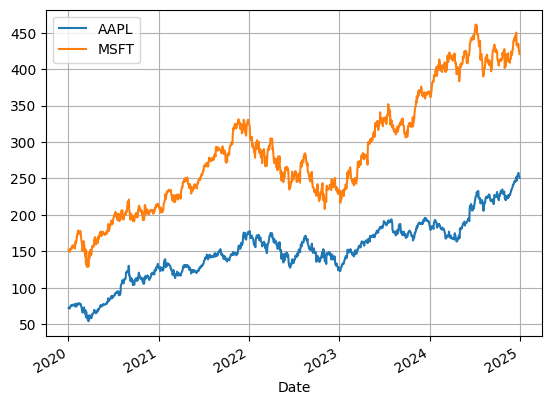

In [4]:
data.plot()
plt.grid()
plt.legend()
plt.show()

### График доходностей


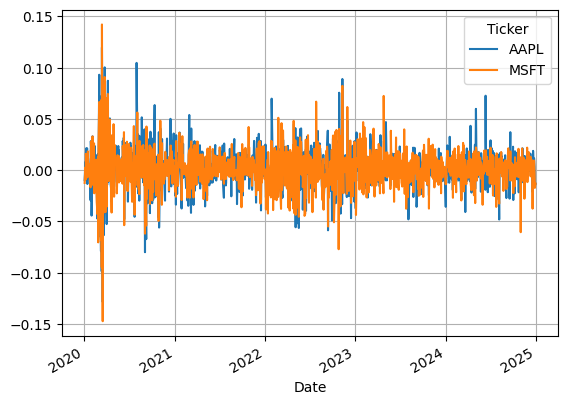

In [5]:
returns.plot()
plt.grid()
plt.show()

### Описательные статистики дневных доходностей

In [6]:
returns.describe()

Ticker,AAPL,MSFT
count,1256.000000,1256.000000
mean,0.001189,0.000995
std,0.019962,0.019217
min,-0.128647,-0.147390
25%,-0.008426,-0.008248
50%,0.001210,0.001113
75%,0.012017,0.010947
max,0.119808,0.142169


### Графики Бокса-Вискера дневных доходностей

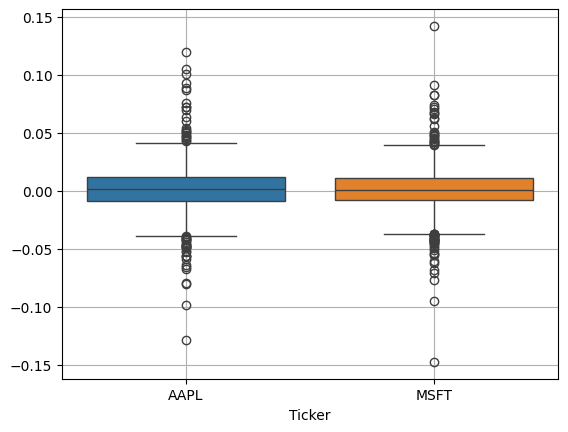

In [7]:
sns.boxplot(returns)
plt.grid()
plt.show()

### Гистограммы распределения дневных доходностей

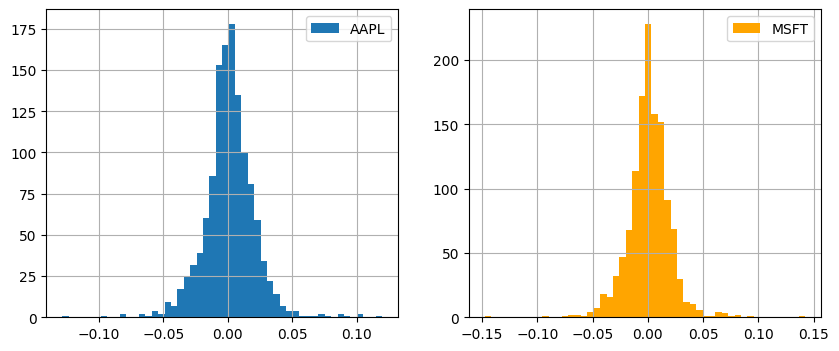

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

ax1.hist(returns['AAPL'], bins=50, label='AAPL')
ax1.grid()
ax1.legend()

ax2.hist(returns['MSFT'], bins=50, color='orange', label='MSFT')
ax2.grid()
ax2.legend()

plt.show()

### Критерии стационарности ряда: ADF-test и KPSS-test

In [9]:
def adf_test(series, title=''):
    print(f'Augmented Dickey-Fuller Test ({title}):')
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical Values: {result[4]}')
    print('Reject H0 (Stationary)' if result[1] <= 0.05 else 'Fail to Reject H0 (Non-Stationary)')
    print('---')

def kpss_test(series, title=''):
    print(f'KPSS Test ({title}):')
    result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'KPSS Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical Values: {result[3]}')
    print('Fail to Reject H0 (Stationary)' if result[1] <= 0.05 else 'Reject H0 (Non-Stationary)')
    print('---')

# Применяем тесты к доходностям
for ticker in tickers:
    adf_test(returns[ticker], title=ticker)
    kpss_test(returns[ticker], title=ticker)

Augmented Dickey-Fuller Test (MSFT):
ADF Statistic: -11.299800
p-value: 0.000000
Critical Values: {'1%': np.float64(-3.4356048614183443), '5%': np.float64(-2.8638605461891617), '10%': np.float64(-2.5680054872544145)}
Reject H0 (Stationary)
---
KPSS Test (MSFT):
KPSS Statistic: 0.095016
p-value: 0.100000
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Reject H0 (Non-Stationary)
---
Augmented Dickey-Fuller Test (AAPL):
ADF Statistic: -11.351125
p-value: 0.000000
Critical Values: {'1%': np.float64(-3.4356048614183443), '5%': np.float64(-2.8638605461891617), '10%': np.float64(-2.5680054872544145)}
Reject H0 (Stationary)
---
KPSS Test (AAPL):
KPSS Statistic: 0.108102
p-value: 0.100000
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Reject H0 (Non-Stationary)
---


/var/folders/_r/xsq315px3ggfhq10dxmkl3fr0000gn/T/ipykernel_2856/3555273386.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')
/var/folders/_r/xsq315px3ggfhq10dxmkl3fr0000gn/T/ipykernel_2856/3555273386.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')


### p-value обоих тестов близко к нулю, ряды стационарны. Значит, можно на их основе построить GARCH-модель

## 2. Построение модели GARCH(1,1) на основе случайных величин

Модель GARCH(1,1) (Generalized Autoregressive Conditional Heteroskedasticity) для временного ряда доходностей $r_t$ записывается как: $$\begin{gathered} r_t = \mu + \varepsilon_t, \\ \varepsilon_t=\sigma_t z_t, \\ \sigma^2_t=\omega + \alpha \varepsilon^2_{t-1} + \beta \sigma^2_{t-1} \end{gathered} $$  где $r_t$ - исследуемый ряд, $z_t$ - случайные величины, $\omega > 0$, $\alpha, \beta \ge 0$, $\alpha + \beta < 1$ (условие стационарности). $\mu$ задаётся в зависимости от центрированности ряда.
На реальных данных параметры чаще всего оцениваются методом максимального правдоподобия. Процесс $r_t$ должен быть процессом с условной гетероскедакстичностью, т. е. может быть представлен следующим образом $r_t = \sigma_t z_t$  

В рамках лабораторной работы для симуляции временных рядов и построения на них модели GARCH, зададим истинные значения $\omega, \alpha, \beta$ и построим ряды из приведённых формул, а затем оценим, как модель оценит эти параметры. $\omega = 0.1, \alpha = 0.1, \beta = 0.8$

In [10]:
def simulate_garch_process(omega: float, alpha: float, beta: float, T: int, distribution, *args):
    r = np.zeros(T)
    sigma2 = np.zeros(T)
    sigma2[0] = omega / (1 - alpha - beta)

    for t in range(1, T):
        sigma2[t] = omega + alpha * (r[t-1]**2) + beta * sigma2[t-1]
        r[t] = np.sqrt(sigma2[t]) * distribution(*args)

    return r, sigma2

OMEGA = 0.1
ALPHA = 0.1
BETA = 0.8
T = 1000
PREDICTION_STEPS = 20

In [11]:
def garch_mse(r, sigma2, T:int):
    slicing = int(T * 0.8)
    train = r[:slicing]
    model_train = arch_model(train, vol='GARCH', p=1, q=1)
    res_train = model_train.fit(disp='off')
    # Прогноз волатильности на 200 шагов вперёд (условной дисперсии)
    forecast = res_train.forecast(horizon=200)
    pred_vol_forecast = np.sqrt(forecast.variance.values[-1, :])  # прогнозные СКО

    # Сравните с истинной волатильностью на тесте (если знаете)
    true_vol_test = sigma2[slicing:]  # из симуляции для индексов 800:1000
    mse_forecast = np.mean((pred_vol_forecast - true_vol_test)**2)
    return mse_forecast

### 2.1. Нормальное распределение

In [50]:
from scipy.optimize import minimize, LinearConstraint

def garch11_norm(sample):
    def garch11_likelihood(params, sample):
        mu, omega, alpha, beta = params
        eps = sample - mu
        T = len(sample)

        sigma2 = np.zeros(T)
        sigma2[0] = np.var(eps)

        for t in range(1,T):
            sigma2[t] = omega + alpha * eps[t-1]**2 + beta * sigma2[t-1]

        loglik = -0.5 * np.sum(np.log(sigma2) + (eps**2) / sigma2)
        return -loglik
    
    init_params = [0., 0.01, 0.1, 0.8]
    bounds = [(None, None), (1e-6, None), (0, 1), (0, 1)]
    constraint = LinearConstraint([[0, 0, 1, 1]], ub=0.999)
    result = minimize(garch11_likelihood, init_params, args=(sample), bounds=bounds, constraints=constraint)
    return result

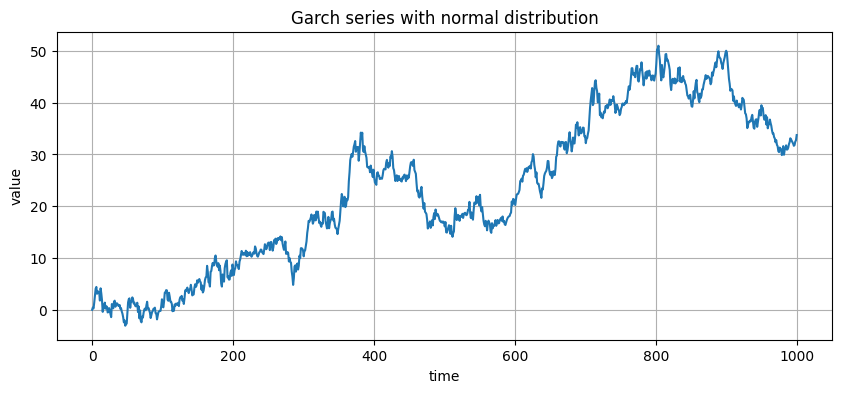

In [51]:
r_norm, sigma2_norm = simulate_garch_process(OMEGA, ALPHA, BETA, T, np.random.normal, 0, 1)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
plt.plot(np.cumsum(r_norm))
plt.title("Garch series with normal distribution")
plt.xlabel("time")
plt.ylabel("value")
plt.grid()
plt.show()

In [52]:
garch11_norm(r_norm)

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 492.3204482661124
           x: [ 3.373e-02  1.009e-01  1.097e-01  7.936e-01]
         nit: 51
         jac: [ 2.331e-03  4.272e-03 -1.375e-02 -6.088e-03]
        nfev: 295
        njev: 48
 multipliers: [ 0.000e+00]

In [15]:
normal_model = arch_model(r_norm[:-PREDICTION_STEPS], vol="GARCH", p=1, q=1, dist='normal')
normal_model_fitted = normal_model.fit(disp="off")
print(normal_model_fitted.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1384.46
Distribution:                  Normal   AIC:                           2776.91
Method:            Maximum Likelihood   BIC:                           2796.47
                                        No. Observations:                  980
Date:                Wed, Apr 08 2026   Df Residuals:                      979
Time:                        17:29:59   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0368  3.101e-02      1.185      0.236 

In [16]:
forecasts_normal = normal_model_fitted.forecast(horizon=PREDICTION_STEPS)
print(f"\nПрогноз дисперсии на {PREDICTION_STEPS} шагов:")
volatility_forecast_normal = forecasts_normal.variance.iloc[-1]
print(volatility_forecast_normal)


Прогноз дисперсии на 20 шагов:
h.01    1.081407
h.02    1.073562
h.03    1.066615
h.04    1.060463
h.05    1.055017
h.06    1.050194
h.07    1.045923
h.08    1.042141
h.09    1.038793
h.10    1.035828
h.11    1.033203
h.12    1.030878
h.13    1.028819
h.14    1.026997
h.15    1.025383
h.16    1.023954
h.17    1.022688
h.18    1.021568
h.19    1.020576
h.20    1.019697
Name: 979, dtype: float64


In [17]:
resid_norm = normal_model_fitted.resid  # r_t
cond_vol_norm = normal_model_fitted.conditional_volatility  # sigma_t
std_resid_norm = resid_norm / cond_vol_norm # z_t

#### Построим график оценённой волатильности / реальной

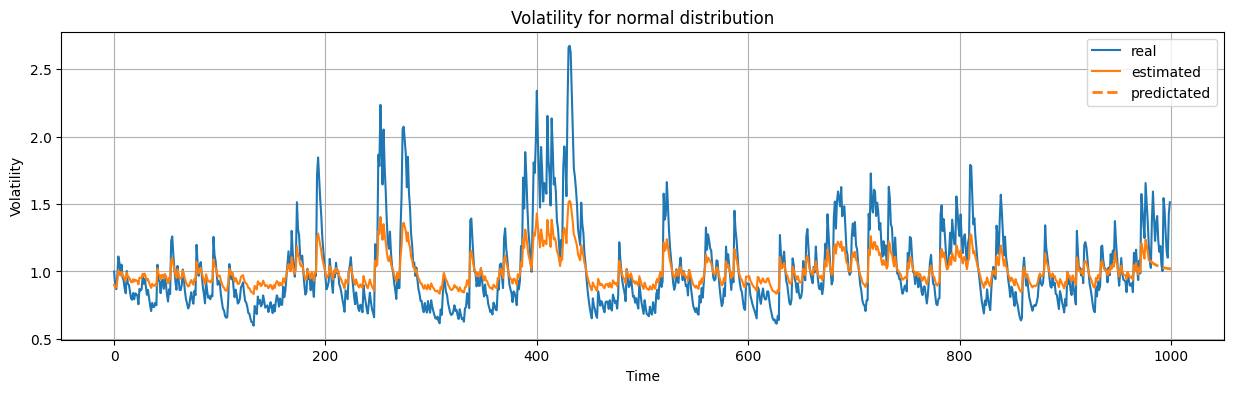

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
plt.plot(sigma2_norm, label="real")
plt.plot(cond_vol_norm, color='tab:orange', label="estimated")

x_predicted = np.linspace(T - PREDICTION_STEPS, T, PREDICTION_STEPS)
plt.plot(x_predicted, volatility_forecast_normal, color='tab:orange', linestyle='--', linewidth=2, label="predictated")

plt.title("Volatility for normal distribution")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.grid()
plt.show()

#### Посчитаем среднюю квадратичную ошибку оценённой волатильности

In [19]:
norm_mse = ((normal_model_fitted.conditional_volatility - sigma2_norm[:-PREDICTION_STEPS]) ** 2).mean()
print(f"MSE : {norm_mse:.4f}")

MSE : 0.0390


#### Оценим параметры нормального распределения (математическое ожидание и дисперсию)

In [20]:
print(f"Estimated mean: {np.mean(std_resid_norm)}")
print(f"Estimated variance: {np.var(std_resid_norm)}")

Estimated mean: 0.007803508767551657
Estimated variance: 0.999882269057906


### 2.2. Variance Gamma

In [21]:
from scipy import special

def vg_rvs(mu, theta, sigma, nu):
    """
    Генерация случайных чисел из VG распределения
    """
    # 1. Генерируем случайное время из гамма-распределения
    # Параметры: shape = 1/nu, scale = nu [citation:3]
    g = np.random.gamma(shape=1/nu, scale=nu)
    
    # 2. Условное нормальное распределение:
    # VG = theta * g + sigma * sqrt(g) * N(0,1)
    # где g - сгенерированное гамма-время
    normal = np.random.normal(0, 1)
    vg = theta * g + sigma * np.sqrt(g) * normal + mu
    
    return vg

def vg_pdf_one_point(x=0.0, c=0.0, sigma=1.0, theta=0.0, nu=1.0):
	''' VarGamma probability density function in a point x '''
	temp1 = 2.0 / ( sigma*(2.0*np.pi)**0.5*nu**(1/nu)*special.gamma(1/nu) )
	temp2 = ((2*sigma**2/nu+theta**2)**0.5)**(0.5-1/nu)
	temp3 = np.exp(theta*(x-c)/sigma**2) * abs(x-c)**(1/nu - 0.5)
	temp4 = special.kv(1/nu - 0.5, abs(x-c)*(2*sigma**2/nu+theta**2)**0.5/sigma**2)
	return temp1*temp2*temp3*temp4

def vg_pdf(x=0.0, c=0.0, sigma=1.0, theta=0.0, nu=1.0):
	''' VarGamma probability density function of an array or a point x '''
	if isinstance(x, (int, float)): # works with lists and arrays
		return vg_pdf_one_point(x, c, sigma, theta, nu)
	else:
		return [vg_pdf_one_point(xi, c, sigma, theta, nu) for xi in x]

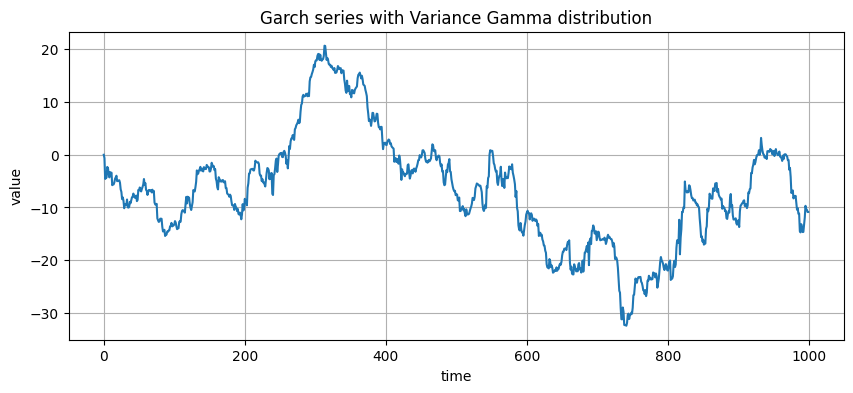

In [22]:
r_vg, sigma2_vg = simulate_garch_process(OMEGA, ALPHA, BETA, T, vg_rvs, 0, 0, 1, 1)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
plt.plot(np.cumsum(r_vg))
plt.title("Garch series with Variance Gamma distribution")
plt.xlabel("time")
plt.ylabel("value")
plt.grid()
plt.show()

In [23]:
vg_model = arch_model(r_vg[:-PREDICTION_STEPS], vol="GARCH", p=1, q=1)
vg_model_fitted = vg_model.fit(disp="off")
print(vg_model_fitted.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1400.81
Distribution:                  Normal   AIC:                           2809.62
Method:            Maximum Likelihood   BIC:                           2829.17
                                        No. Observations:                  980
Date:                Wed, Apr 08 2026   Df Residuals:                      979
Time:                        17:30:01   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu            -0.0302  3.308e-02     -0.913      0.361 

In [24]:
forecasts_vg = vg_model_fitted.forecast(horizon=PREDICTION_STEPS)
print(f"\nПрогноз дисперсии на {PREDICTION_STEPS} шагов:")
volatility_forecast_vg = forecasts_vg.variance.iloc[-1]
print(volatility_forecast_vg)


Прогноз дисперсии на 20 шагов:
h.01    1.250242
h.02    1.222887
h.03    1.200026
h.04    1.180920
h.05    1.164952
h.06    1.151608
h.07    1.140455
h.08    1.131135
h.09    1.123345
h.10    1.116835
h.11    1.111394
h.12    1.106848
h.13    1.103047
h.14    1.099872
h.15    1.097217
h.16    1.094999
h.17    1.093146
h.18    1.091596
h.19    1.090301
h.20    1.089219
Name: 979, dtype: float64


In [25]:
resid_vg = vg_model_fitted.resid  # r_t
cond_vol_vg = vg_model_fitted.conditional_volatility  # sigma_t
std_resid_vg = resid_vg / cond_vol_vg # z_t

#### Построим график оценённой волатильности / реальной

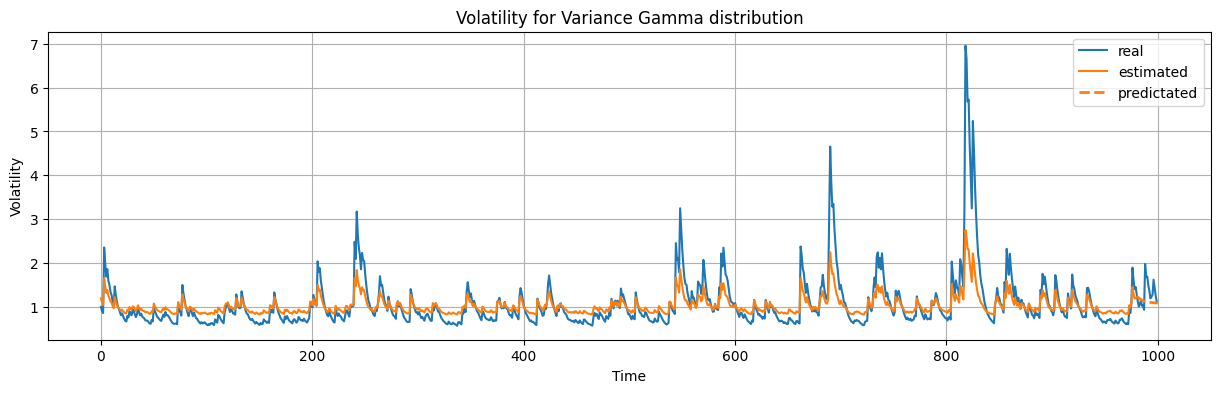

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
plt.plot(sigma2_vg, label="real")
plt.plot(cond_vol_vg, color='tab:orange', label="estimated")

x_predicted = np.linspace(T - PREDICTION_STEPS, T, PREDICTION_STEPS)
plt.plot(x_predicted, volatility_forecast_vg, color='tab:orange', linestyle='--', linewidth=2, label="predictated")

plt.title("Volatility for Variance Gamma distribution")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.grid()
plt.show()

#### Среднеквадратичная ошибка оценки волатильности

In [27]:
norm_mse = ((vg_model_fitted.conditional_volatility - sigma2_vg[:-PREDICTION_STEPS]) ** 2).mean()
print(f"MSE : {norm_mse:.4f}")

MSE : 0.1710


#### Оценим параметры Variance Gamma распределения ($\mu,\ \sigma,\ \theta,\ \nu$)

In [28]:
def vg_moments_method(x):
	''' fits the parameters of VarGamma distribution to a given list of points
		via method of moments, assumes that theta is small (so theta^2 = 0)
		see: Seneta, E. (2004). Fitting the variance-gamma model to financial data. '''
	mu = np.mean(x)
	sigma_squared = np.mean( (x-mu)**2 )
	beta = np.mean( (x-mu)**3 ) / np.mean( (x-mu)**2 )**1.5
	kapa = np.mean( (x-mu)**4 ) / np.mean( (x-mu)**2 )**2
	# solve combined equations
	sigma = sigma_squared**0.5
	nu = kapa/3.0 - 1.0
	theta = sigma*beta / (3.0*nu)
	c = mu - theta
	return (c, sigma, theta, nu)

vg_moments = vg_moments_method(std_resid_vg)
#print(rf"$\mu$ = {moments["mu"]}, $\theta$ = {moments["theta"]}, $\sigma$ = {moments["sigma"]}, $\nu$ = {moments["nu"]}, ")
print("mu:", vg_moments[0], "sigma:", vg_moments[1], "theta:", vg_moments[2], "nu:", vg_moments[3])

mu: 0.049512485066410664 sigma: 1.0026738251052345 theta: -0.042008283455375835 nu: 0.8662987058365159


#### 3. $\alpha$-устойчивое распределение

В качестве $\alpha$ выберем 1.9

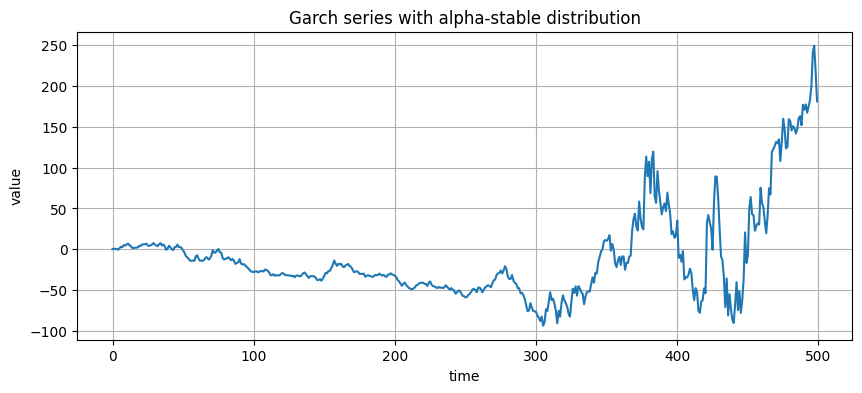

In [29]:
r_alpha_stable, sigma2_as = simulate_garch_process(OMEGA, ALPHA, BETA, 500, stats.levy_stable.rvs, 1.9, 0, 0, 1)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
plt.plot(np.cumsum(r_alpha_stable))
plt.title("Garch series with alpha-stable distribution")
plt.xlabel("time")
plt.ylabel("value")
plt.grid()
plt.show()

In [30]:
as_model = arch_model(r_alpha_stable[:-PREDICTION_STEPS], vol="GARCH", p=1, q=1, dist='normal')
as_model_fitted = as_model.fit(disp="off")
print(as_model_fitted.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1451.21
Distribution:                  Normal   AIC:                           2910.42
Method:            Maximum Likelihood   BIC:                           2927.12
                                        No. Observations:                  480
Date:                Wed, Apr 08 2026   Df Residuals:                      479
Time:                        17:30:05   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu            -0.1234      0.112     -1.106      0.269 [ -0.342,

In [31]:
forecasts_as = as_model_fitted.forecast(horizon=PREDICTION_STEPS)
print(f"\nПрогноз дисперсии на {PREDICTION_STEPS} шагов:")
volatility_forecast_as = forecasts_as.variance.iloc[-1]
print(volatility_forecast_as)


Прогноз дисперсии на 20 шагов:
h.01    526.686189
h.02    526.751205
h.03    526.816221
h.04    526.881237
h.05    526.946253
h.06    527.011269
h.07    527.076285
h.08    527.141301
h.09    527.206317
h.10    527.271333
h.11    527.336349
h.12    527.401365
h.13    527.466380
h.14    527.531396
h.15    527.596412
h.16    527.661428
h.17    527.726444
h.18    527.791460
h.19    527.856476
h.20    527.921492
Name: 479, dtype: float64


In [32]:
resid_as = as_model_fitted.resid  # r_t
cond_vol_as = as_model_fitted.conditional_volatility  # sigma_t
std_resid_as = resid_as / cond_vol_as # z_t

#### Построим график оценённой волатильности / реальной

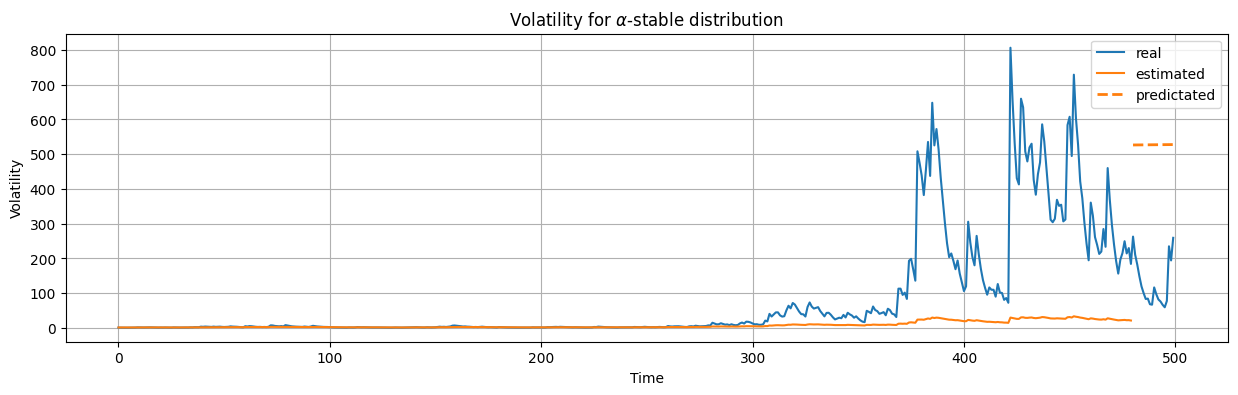

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
plt.plot(sigma2_as, label="real")
plt.plot(cond_vol_as, color='tab:orange', label="estimated")

x_predicted = np.linspace(len(sigma2_as) - PREDICTION_STEPS, len(sigma2_as), PREDICTION_STEPS)
plt.plot(x_predicted, volatility_forecast_as, color='tab:orange', linestyle='--', linewidth=2, label="predictated")

plt.title(fr"Volatility for $\alpha$-stable distribution")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.grid()
plt.show()

#### Оценка параметров распределения

In [34]:
moments = stats.levy_stable.fit(std_resid_as)
print(rf"$\mu$ = {moments[2]}, $\alpha$ = {moments[0]}, $\sigma$ = {moments[3]}, $\beta$ = {moments[1]}, ")

$\mu$ = -0.023447611845345398, $\alpha$ = 1.9999999999999982, $\sigma$ = 0.7591582014698623, $\beta$ = 0.9999999999999996, 


#### Среднеквадратчная ошибка волатильности

In [35]:
norm_mse = ((as_model_fitted.conditional_volatility - sigma2_as[:-PREDICTION_STEPS]) ** 2).mean()
print(f"MSE : {norm_mse:.4f}")

MSE : 26594.6636


## 5. GARCH(1,1) на реальных данных

In [36]:
returns_scaled = returns * 100
model = arch_model(returns_scaled['AAPL'])
model_fitted = model.fit(disp='off')

In [37]:
print(model_fitted.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   AAPL   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2507.20
Distribution:                  Normal   AIC:                           5022.39
Method:            Maximum Likelihood   BIC:                           5042.93
                                        No. Observations:                 1256
Date:                Wed, Apr 08 2026   Df Residuals:                     1255
Time:                        17:30:09   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1592  5.124e-02      3.107  1.891e-03 [5.877e-0

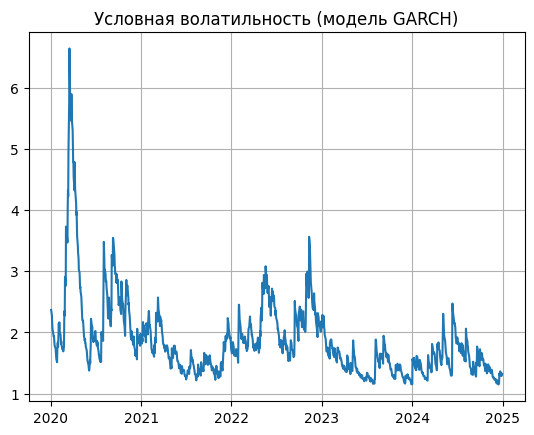

In [38]:
conditional_volatility = model_fitted.conditional_volatility
plt.plot(conditional_volatility)
plt.title('Условная волатильность (модель GARCH)')
plt.grid()
plt.show()

In [39]:
forecasts = model_fitted.forecast(horizon=5)
print("\nПрогноз дисперсии на 5 шагов:")
print(forecasts.variance.iloc[-1])


Прогноз дисперсии на 5 шагов:
h.1    1.848059
h.2    1.899600
h.3    1.949712
h.4    1.998434
h.5    2.045805
Name: 2024-12-30 00:00:00, dtype: float64


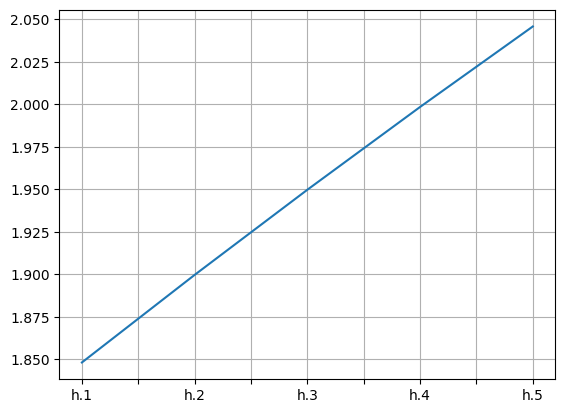

In [40]:
forecasts.variance.iloc[-1].plot()
plt.grid()
plt.show()

In [41]:
test_data = yf.download('AAPL', start='2025-01-01', end='2025-12-31')['Close']  # type: ignore
returns_test = test_data.pct_change().dropna()
test_data.head()

[*********************100%***********************]  1 of 1 completed


Ticker,AAPL
Date,
2025-01-02,242.525162
2025-01-03,242.037811
2025-01-06,243.668900
2025-01-07,240.894073
2025-01-08,241.381409


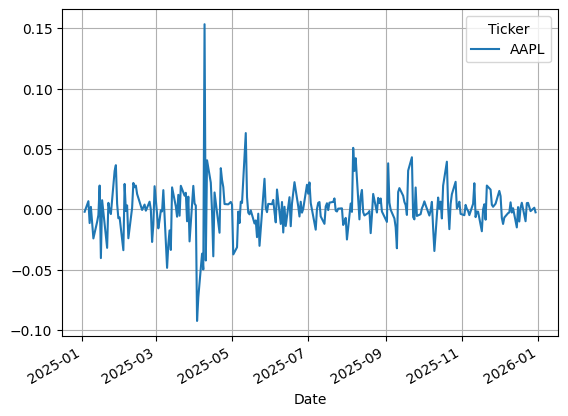

In [42]:
returns_test.plot()
#forecasts.variance.iloc[-1].plot()
plt.grid()
plt.show()